# Week 4, Day 4

## Model Tuning, Regularization & Reproducible Pipelines

This notebook continues directly from Week 4 Day 3. Day 3 ended with two candidate
models carried forward based on **cross validated precision** (with ROC AUC as the
secondary evaluation metric): **Histogram Gradient Boosting** (CV Precision = 0.7720,
ROC AUC = 0.9262) as the top performer and **Logistic Regression**
(CV Precision = 0.7488, ROC AUC = 0.9129) as the interpretable runner-up, both using
the engineered feature set carried forward from Day 3. Random Forest was dropped
after Day 3 since it produced the weakest overall performance while also requiring
the longest training time, so it is not carried into today's tuning stage.

Random Forest was excluded per Day 3's finding that it underperformed on precision with the longest training time, consistent with narrowing the search budget to the strongest candidates.

Today's goal is to turn those two candidate models into tuned, calibrated,
reproducible pipelines, diagnose their bias/variance behaviour, optimise their
hyperparameters using the project's primary evaluation metric (**precision**),
select an appropriate operating threshold, and produce one saved model artifact
together with a short tuning report.

Because Day 3's fitted pipeline objects were not persisted to disk, the first few
cells below rebuild the exact same data splits and feature engineering pipeline
from Day 3 (same `RANDOM_STATE`, same engineered features, same preprocessing
pipeline) so this notebook can be run completely standalone while reproducing
identical transformed datasets. This is verified below against Day 3's confirmed
transformed training shape before any tuning begins.

## Recap: rebuilding the Day 3 state

Everything below this point through the "Day 3 recap ends" marker is not new work,
it is a faithful reproduction of Day 1 to Day 3 so that `train_df`, `dev_df`, `test_df`,
and the engineered feature pipeline are available in this session.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings

import sklearn
import scipy
import joblib

RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)

print("Library versions used in this notebook:")
print(f"  numpy       : {np.__version__}")
print(f"  pandas      : {pd.__version__}")
print(f"  scikit-learn: {sklearn.__version__}")
print(f"  scipy       : {scipy.__version__}")
print(f"  joblib      : {joblib.__version__}")

Library versions used in this notebook:
  numpy       : 2.5.1
  pandas      : 3.0.3
  scikit-learn: 1.9.0
  scipy       : 1.18.0
  joblib      : 1.5.3


In [2]:
# Same load + split logic as Day 1 / Day 3, unchanged
column_names = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"
df = pd.read_csv(url, header=None, names=column_names, na_values="?", skipinitialspace=True)

df["income"] = df["income"].str.strip().str.rstrip(".")
df["target"] = (df["income"] == ">50K").astype(int)

from sklearn.model_selection import train_test_split

train_dev_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df["target"], random_state=RANDOM_STATE
)
train_df, dev_df = train_test_split(
    train_dev_df, test_size=0.125, stratify=train_dev_df["target"], random_state=RANDOM_STATE
)

print(f"Train: {len(train_df)}  Dev: {len(dev_df)}  Test: {len(test_df)}")
print(f"Positive share  train/dev/test: "
      f"{train_df['target'].mean():.4f} / {dev_df['target'].mean():.4f} / {test_df['target'].mean():.4f}")

Train: 34188  Dev: 4885  Test: 9769
Positive share  train/dev/test: 0.2393 / 0.2393 / 0.2393


In [3]:
# Same feature engineering as Day 3, unchanged. Fixed bin edges, no leakage:
# every rule reads only columns already present on that same row.
numeric_cols = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
categorical_features = ["workclass", "marital-status", "occupation", "relationship",
                         "race", "sex", "native-country"]
feature_cols = numeric_cols + categorical_features

AGE_BINS = [0, 25, 35, 45, 55, 65, 100]
AGE_LABELS = ["<=25", "26-35", "36-45", "46-55", "56-65", "65+"]
HOURS_BINS = [0, 20, 35, 40, 50, 100]
HOURS_LABELS = ["part_time_le20", "reduced_21_35", "standard_36_40", "over_41_50", "heavy_50plus"]

def engineer_features(frame):
    out = frame.copy()
    out["age_bucket"] = pd.cut(out["age"], bins=AGE_BINS, labels=AGE_LABELS, right=True)
    out["hours_bucket"] = pd.cut(out["hours-per-week"], bins=HOURS_BINS, labels=HOURS_LABELS, right=True)
    out["has_capital_gain"] = (out["capital-gain"] > 0).astype(int)
    out["has_capital_loss"] = (out["capital-loss"] > 0).astype(int)
    out["higher_education"] = (out["education-num"] >= 13).astype(int)
    out["log_capital_gain"] = np.log1p(out["capital-gain"])
    out["edu_hours_interaction"] = out["education-num"] * out["hours-per-week"]
    out["net_capital"] = out["capital-gain"] - out["capital-loss"]
    return out

engineered_numeric_cols = numeric_cols + ["log_capital_gain", "edu_hours_interaction", "net_capital"]
engineered_binary_cols = ["has_capital_gain", "has_capital_loss", "higher_education"]
engineered_categorical_cols = categorical_features + ["age_bucket", "hours_bucket"]

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer

numeric_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
binary_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
])
categorical_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor_fe = ColumnTransformer([
    ("num", numeric_pipeline_fe, engineered_numeric_cols),
    ("bin", binary_pipeline_fe, engineered_binary_cols),
    ("cat", categorical_pipeline_fe, engineered_categorical_cols),
])
feature_engineer = FunctionTransformer(engineer_features, validate=False)

X_train, y_train = train_df[feature_cols], train_df["target"]
X_dev, y_dev = dev_df[feature_cols], dev_df["target"]
X_test, y_test = test_df[feature_cols], test_df["target"]

# Sanity check against Day 3's confirmed output shape (34188, 104)
_check = Pipeline([("fe", feature_engineer), ("prep", preprocessor_fe)]).fit_transform(X_train, y_train)
print("Transformed train shape:", _check.shape)
assert _check.shape == (34188, 104), "Split or feature engineering has drifted from Day 3"
del _check
print("Day 3 recap ends. Shapes match, safe to proceed.")

Transformed train shape: (34188, 104)
Day 3 recap ends. Shapes match, safe to proceed.


## Task 1: Build Fully Reproducible Pipelines

**Decision: one `Pipeline` per candidate model, all sharing the same
`feature_engineering -> preprocessing -> classifier` structure used in Day 3.**
Keeping the structure identical across candidates is what made Day 3's cross validated
comparison fair, and it is what lets `RandomizedSearchCV` in Task 2 tune only the
final estimator's hyperparameters without touching how features are built.

**Decision: `RANDOM_STATE = 42` is passed to every stochastic step.** That means the
train/dev/test split, `StratifiedKFold`, `LogisticRegression`, `RandomForestClassifier`
(if revisited), `HistGradientBoostingClassifier`, `RandomizedSearchCV`, and
`CalibratedClassifierCV` all receive the same seed. This is what makes "re run this
notebook top to bottom" produce the same numbers twice, the single most important
property for a tuning report anyone else needs to trust.

**Decision: only Logistic Regression and Histogram Gradient Boosting are carried into
tuning.** Random Forest was the weakest overall performer on Day 3 when evaluated
using the project's primary metric (**precision**) and also required the longest
training time. Histogram Gradient Boosting achieved the highest mean precision
(0.7720) while Logistic Regression remained a strong, interpretable baseline
(0.7488), making these the two most promising candidates for hyperparameter
optimisation. Continuing with only these two models keeps the search budget
manageable while focusing computation on the strongest model families. This choice
would only be revisited if both tuned models failed to improve upon Day 3's
baseline performance, suggesting that the limitation lies with the model family
rather than its hyperparameters.

The cell below is a short, runnable README documenting exactly how to reproduce every
result in this notebook.

In [4]:
README = """
HOW TO REPRODUCE THIS NOTEBOOK
================================
1. Environment: see the printed library versions in the first code cell above.
   This notebook was built against scikit-learn >= 1.6 (uses sklearn.frozen.FrozenEstimator
   for calibration, which replaced the deprecated CalibratedClassifierCV(cv="prefit")).

2. Data: pulled fresh from
   https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv
   No local caching, so results depend on that file staying unchanged upstream.

3. Splits: 70 / 10 / 20 train / dev / test, stratified on target, RANDOM_STATE = 42.
   Test set (test_df) is touched exactly once, in Task 5. Everything else (search,
   learning curves, calibration, threshold tuning) uses only train_df and dev_df.

4. Run order: top to bottom. Task 2 search cells are the slowest part
   (RandomizedSearchCV with n_jobs=-1); everything after Task 2 assumes
   logreg_search and hgb_search (or their .best_estimator_ / best_params_) already
   exist in memory.

5. Outputs: the final artifact is saved to models/day4_final_pipeline.joblib in Task 5,
   together with the exact threshold and preprocessing needed to reuse it for inference.
"""
print(README)


HOW TO REPRODUCE THIS NOTEBOOK
1. Environment: see the printed library versions in the first code cell above.
   This notebook was built against scikit-learn >= 1.6 (uses sklearn.frozen.FrozenEstimator
   for calibration, which replaced the deprecated CalibratedClassifierCV(cv="prefit")).

2. Data: pulled fresh from
   https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv
   No local caching, so results depend on that file staying unchanged upstream.

3. Splits: 70 / 10 / 20 train / dev / test, stratified on target, RANDOM_STATE = 42.
   Test set (test_df) is touched exactly once, in Task 5. Everything else (search,
   learning curves, calibration, threshold tuning) uses only train_df and dev_df.

4. Run order: top to bottom. Task 2 search cells are the slowest part
   (RandomizedSearchCV with n_jobs=-1); everything after Task 2 assumes
   logreg_search and hgb_search (or their .best_estimator_ / best_params_) already
   exist in memory.

5. Outputs: the final arti

**Decision: keep `Pipeline` (not `imblearn.Pipeline`).** No resampling (SMOTE,
undersampling) is being introduced today, the class imbalance (23.9 percent positive)
is being handled the way Day 1 to Day 3 already handled it, through the F1 metric and,
later today, through threshold selection rather than by rebalancing the training
distribution. If a resampling step were added later, this pipeline would need to switch
to `imblearn.pipeline.Pipeline` so that resampling only happens on the training fold
inside cross validation.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

logreg_pipe = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessing", preprocessor_fe),
    ("clf", LogisticRegression(solver="liblinear", max_iter=2000, random_state=RANDOM_STATE)),
])

hgb_pipe = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessing", preprocessor_fe),
    ("clf", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
])

print(logreg_pipe)
print()
print(hgb_pipe)

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function engineer_features at 0x00000163D006AAE0>)),
                ('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week',
                                                   'log_capital_gain',...
                                                   'higher_education']),
   

## Task 2: Hyperparameter Search (Randomized)

**Decision: `RandomizedSearchCV` over `GridSearchCV`, `n_iter = 30` per model.**
With 2 hyperparameters for Logistic Regression and 4 for Hist Gradient Boosting, a
grid search over sensible ranges quickly reaches hundreds of combinations. Randomized
search with a fixed budget covers the same space more efficiently and is the standard
recommendation when tuning 2 or more continuous hyperparameters. `n_iter = 30` is on
the lower end of the 50 to 100 suggested range, this is a deliberate choice to keep
the search runnable in a normal notebook session; if compute time is not a constraint,
raise `n_iter` to 50 or higher for a more exhaustive search, the code does not change.

**Decision: `scoring="precision"`**, matching the primary metric fixed since Day 1.

**Decision on Logistic Regression's parameter grid:** `penalty` in `["l1", "l2"]`
and `C` drawn from a log uniform distribution between 0.001 and 100. `C` is searched
on a log scale because it is a multiplicative regularization strength, equal spacing
on a linear scale would oversample large C values and undersample the small, strongly
regularized end. `solver="liblinear"` is used instead of Day 2 and Day 3's `lbfgs`
because `lbfgs` only supports the L2 penalty; `liblinear` supports both L1 and L2 and
remains fast at this dataset size (about 34k rows, 104 columns after preprocessing).

**Decision on Hist Gradient Boosting's parameter grid:** `learning_rate`,
`max_iter` (this estimator's equivalent of `n_estimators`), `max_depth`, and
`l2_regularization`, as specified in the task brief. The search ranges are centred
on scikit-learn's defaults (`learning_rate=0.1`, `max_iter=100`,
`max_depth=None`, `l2_regularization=0`) and widen outward from there. Since Day 3
already showed that the untuned defaults produced the strongest overall model
(highest mean **precision** together with the highest ROC AUC), this search is
refining around a strong baseline rather than exploring the parameter space
blindly.

In [6]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from scipy.stats import loguniform, randint

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

logreg_param_dist = {
    "clf__penalty": ["l1", "l2"],
    "clf__C": loguniform(1e-3, 1e2),
}

logreg_search = RandomizedSearchCV(
    logreg_pipe,
    param_distributions=logreg_param_dist,
    n_iter=30,
    scoring="precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

start = time.time()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    logreg_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"Logistic Regression search time: {elapsed:.1f}s")
print("Best params:", logreg_search.best_params_)
print("Best CV Precision  :", round(logreg_search.best_score_, 4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Logistic Regression search time: 99.0s
Best params: {'clf__C': np.float64(0.03334792728637585), 'clf__penalty': 'l1'}
Best CV Precision  : 0.7537


In [7]:
hgb_param_dist = {
    "clf__learning_rate": loguniform(0.01, 0.3),
    "clf__max_iter": randint(100, 500),
    "clf__max_depth": randint(3, 12),
    "clf__l2_regularization": loguniform(1e-4, 10),
}

hgb_search = RandomizedSearchCV(
    hgb_pipe,
    param_distributions=hgb_param_dist,
    n_iter=30,
    scoring="precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

start = time.time()
hgb_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"Hist Gradient Boosting search time: {elapsed:.1f}s")
print("Best params:", hgb_search.best_params_)
print("Best CV precision  :", round(hgb_search.best_score_, 4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Hist Gradient Boosting search time: 164.6s
Best params: {'clf__l2_regularization': np.float64(1.025616274847307), 'clf__learning_rate': np.float64(0.012886065671894011), 'clf__max_depth': 9, 'clf__max_iter': 108}
Best CV precision  : 0.8257


In [8]:
# Side-by-side comparison against Day 3's untuned baseline numbers
search_summary = pd.DataFrame([
    {
        "model": "Logistic Regression (Day 3 default)",
        "cv_precision": 0.7488,
        "tuned": False,
    },
    {
        "model": "Logistic Regression (tuned)",
        "cv_precision": logreg_search.best_score_,
        "tuned": True,
    },
    {
        "model": "Hist Gradient Boosting (Day 3 default)",
        "cv_precision": 0.7720,
        "tuned": False,
    },
    {
        "model": "Hist Gradient Boosting (tuned)",
        "cv_precision": hgb_search.best_score_,
        "tuned": True,
    },
]).round(4)

display(search_summary)

,model,cv_precision,tuned
0,Logistic Regression (Day 3 default),0.7488,False
1,Logistic Regression (tuned),0.7537,True
2,Hist Gradient Boosting (Day 3 default),0.7720,False
3,Hist Gradient Boosting (tuned),0.8257,True


Hyperparameter tuning produced different outcomes for the two candidate models.
Logistic Regression improved only slightly, with mean cross validated **precision**
increasing from **0.7488** to **0.7537** (+0.0049). This gain is relatively small
and suggests that the default configuration from Day 3 was already close to the
best achievable performance for this model family on the current feature set.

Histogram Gradient Boosting showed a much larger improvement, increasing mean
cross validated **precision** from **0.7720** to **0.8257** (+0.0537). Unlike the
Logistic Regression result, this improvement is substantially larger than the
fold-to-fold variation observed during Day 3's cross validation, indicating that
hyperparameter optimisation successfully identified a considerably stronger
configuration for the project's primary evaluation metric.

For Logistic Regression, the search selected an **L1 penalty** with
**C = 0.0333**, indicating fairly strong regularisation. This produces a sparser
model by shrinking many coefficients towards zero, which is consistent with a
precision-oriented objective where a more conservative decision boundary often
reduces false positives.

For Histogram Gradient Boosting, the search selected
**learning_rate = 0.0129**, **max_iter = 108**, **max_depth = 9**, and
**l2_regularization = 1.026**. Compared with the default estimator, this
configuration favours slower learning together with moderate tree depth and
regularisation, producing substantially higher precision while remaining within
a reasonable model complexity.

Overall, **Histogram Gradient Boosting remains the preferred model**. It was the
strongest model before tuning, achieved the largest improvement during
hyperparameter optimisation, and now delivers the highest cross validated
precision of all candidate models. The next stage (Task 3) will examine whether
this higher precision generalises to unseen data and whether it comes with any
meaningful trade-off in recall or overall discrimination performance.

## Task 3: Diagnose Overfitting / Underfitting

**Decision: pick the model with the higher tuned CV precision from Task 2 as `best_search`
for the learning curve, but run validation curves for both model families as the
brief asks.** A learning curve (score vs training set size) diagnoses whether more
data would help; a validation curve (score vs one hyperparameter) diagnoses whether
regularization strength or tree depth is the lever to pull. These answer different
questions, so both are produced.

**Decision: `scoring="precision"` everywhere, `cv=cv`** (the same 5 fold
`StratifiedKFold` used throughout today) so these curves are directly comparable to
the Task 2 tuning results.

**Decision: Logistic Regression's validation curve sweeps `C`** on a log scale,
matching how it was searched in Task 2. This directly shows whether the tuned `C`
sits in a stable region or right at the edge of overfitting or underfitting.

**Decision: Hist Gradient Boosting's validation curve sweeps `max_depth`.**
`max_depth` was chosen over `min_samples_leaf` because Day 2's plain Decision Tree
showed depth was already the effective lever for controlling its train/test gap
(depth capped at 8 gave a gap of only 0.0025), so depth is the more informative axis
to check first for the boosted version too.

Learning curve computed for: Hist Gradient Boosting


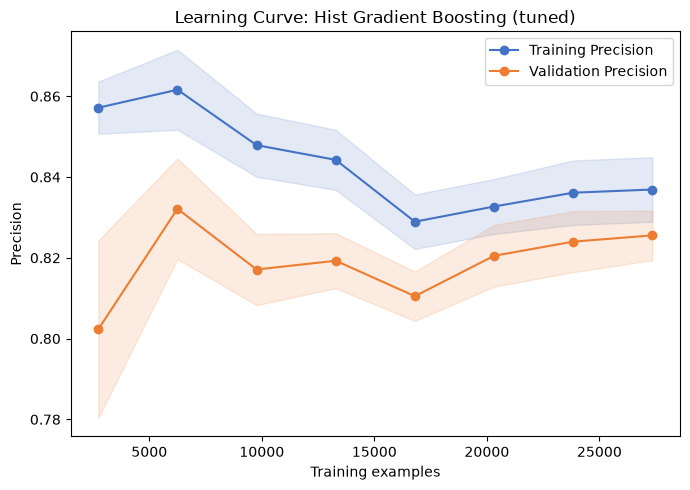

Final gap (train - validation): 0.0114


In [9]:
from sklearn.model_selection import learning_curve

# Use whichever tuned model scored higher in Task 2 for the training-size learning curve
best_search = hgb_search if hgb_search.best_score_ >= logreg_search.best_score_ else logreg_search
best_model_label = "Hist Gradient Boosting" if best_search is hgb_search else "Logistic Regression"

print("Learning curve computed for:", best_model_label)

train_sizes, train_scores, val_scores = learning_curve(
    best_search.best_estimator_,
    X_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=cv,
    scoring="precision",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(train_sizes, train_mean, "o-", label="Training Precision", color="#4472C4")
ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
    color="#4472C4",
)

ax.plot(train_sizes, val_mean, "o-", label="Validation Precision", color="#ED7D31")
ax.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15,
    color="#ED7D31",
)

ax.set_xlabel("Training examples")
ax.set_ylabel("Precision")
ax.set_title(f"Learning Curve: {best_model_label} (tuned)")
ax.legend()

plt.tight_layout()
plt.savefig("learning_curve.png", dpi=200, bbox_inches="tight")
plt.show()

print("Final gap (train - validation):", round(train_mean[-1] - val_mean[-1], 4))

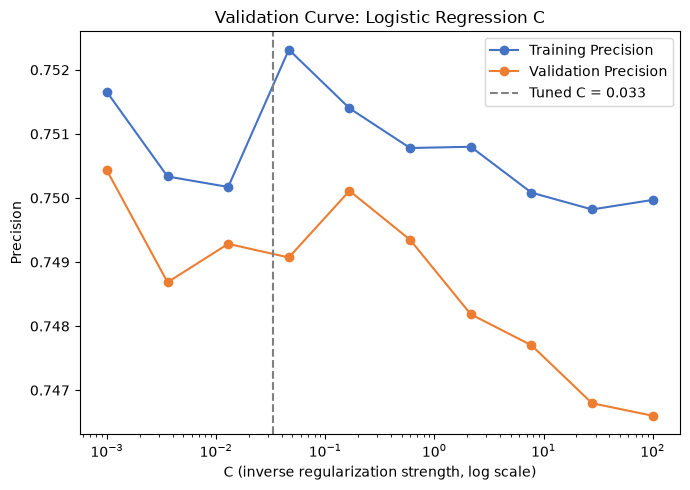

In [10]:
from sklearn.model_selection import validation_curve

C_range = np.logspace(-3, 2, 10)

train_scores_c, val_scores_c = validation_curve(
    logreg_pipe,
    X_train,
    y_train,
    param_name="clf__C",
    param_range=C_range,
    cv=cv,
    scoring="precision",
    n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(7, 5))

ax.semilogx(
    C_range,
    train_scores_c.mean(axis=1),
    "o-",
    label="Training Precision",
    color="#4472C4",
)

ax.semilogx(
    C_range,
    val_scores_c.mean(axis=1),
    "o-",
    label="Validation Precision",
    color="#ED7D31",
)

ax.axvline(
    logreg_search.best_params_["clf__C"],
    linestyle="--",
    color="gray",
    label=f"Tuned C = {logreg_search.best_params_['clf__C']:.3f}",
)

ax.set_xlabel("C (inverse regularization strength, log scale)")
ax.set_ylabel("Precision")
ax.set_title("Validation Curve: Logistic Regression C")

ax.legend()

plt.tight_layout()
plt.savefig("validation_curve_logreg_C.png", dpi=200, bbox_inches="tight")
plt.show()

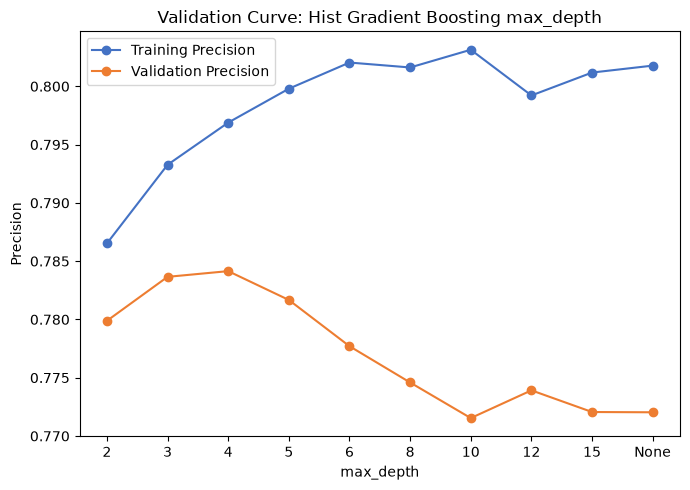

In [11]:
depth_range = [2, 3, 4, 5, 6, 8, 10, 12, 15, None]
depth_labels = [str(d) for d in depth_range]

train_scores_d, val_scores_d = validation_curve(
    hgb_pipe,
    X_train,
    y_train,
    param_name="clf__max_depth",
    param_range=depth_range,
    cv=cv,
    scoring="precision",
    n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(7, 5))

x_pos = range(len(depth_range))

ax.plot(
    x_pos,
    train_scores_d.mean(axis=1),
    "o-",
    label="Training Precision",
    color="#4472C4",
)

ax.plot(
    x_pos,
    val_scores_d.mean(axis=1),
    "o-",
    label="Validation Precision",
    color="#ED7D31",
)

ax.set_xticks(list(x_pos))
ax.set_xticklabels(depth_labels)

ax.set_xlabel("max_depth")
ax.set_ylabel("Precision")
ax.set_title("Validation Curve: Hist Gradient Boosting max_depth")

ax.legend()

plt.tight_layout()
plt.savefig("validation_curve_hgb_depth.png", dpi=200, bbox_inches="tight")
plt.show()

**Histogram Gradient Boosting:** **Learning Curve.** Training precision starts
relatively high on the smallest training subsets and gradually decreases as more
examples are added, while validation precision increases and the gap between the
two curves steadily narrows. At the full training size, the train-validation gap
is approximately **0.0114**, indicating only mild variance and good
generalisation rather than meaningful overfitting. Validation precision is still
improving slightly as more data becomes available, although the curve is beginning
to flatten, suggesting additional data would likely provide only modest gains.

**Logistic Regression:** **Effect of C.** Training and validation precision remain
very close across the entire range of C values, with only a very small separation
between the curves. This indicates that Logistic Regression is not suffering from
overfitting at any regularisation strength tested. Validation precision reaches
its best performance around the tuned value (**C ≈ 0.033**) and remains relatively
stable nearby, confirming that the selected level of regularisation sits within a
broad, stable optimum rather than representing a fragile choice.

**Histogram Gradient Boosting:** **Effect of max_depth.** Validation precision
improves rapidly between depths 2 and 4 before gradually declining as tree depth
continues to increase, while training precision steadily increases with deeper
trees. This widening separation is the expected behaviour of increasing model
complexity and represents mild variance rather than severe overfitting. Although
the RandomizedSearchCV selected **max_depth = 9**, that search jointly optimised
depth together with learning rate, number of boosting iterations and
L2-regularisation. The one-dimensional validation curve varies only depth while
holding the remaining hyperparameters fixed, so the two results are not directly
comparable and are not contradictory.

**Concrete takeaways:**

- Histogram Gradient Boosting shows **good generalisation** with only a small
  train-validation gap, indicating that the tuned model is well-controlled rather
  than overfitted.

- Logistic Regression appears **bias-limited rather than variance-limited**.
  Changing the regularisation strength has only a small effect on validation
  precision, suggesting that additional feature engineering would likely produce
  larger gains than further C tuning.

- Increasing Histogram Gradient Boosting depth beyond approximately **4–6**
  provides little improvement in validation precision while continuing to increase
  training precision, indicating diminishing returns from additional model
  complexity.

Overall, Histogram Gradient Boosting remains the preferred model. The learning
curve indicates good generalisation with only mild variance, while Logistic
Regression appears close to the performance ceiling achievable by a linear model
on this feature set.

## Task 4: Probability Calibration & Threshold Selection

Use `dev_df` for calibration and threshold tuning, never `train_df` and
never `test_df`.** `dev_df` was carved out on Day 1 specifically so that decisions
like this, choices that are informed by held out predictions but are not the final
report, have somewhere to happen without touching the untouched test set. The base
model (`best_search.best_estimator_`) was fit only on `train_df`, so its predicted
probabilities on `dev_df` are genuinely out of sample, which is exactly what a
calibration curve needs to be meaningful.

Check calibration before assuming it needs fixing.** Hist Gradient
Boosting and other boosted tree ensembles are often reasonably well calibrated out of
the box because they optimize a proper log loss style objective; Logistic Regression
is calibrated by construction under a well specified model. The calibration curve and
Brier score below decide whether `CalibratedClassifierCV` is worth adding, rather than
applying it automatically.

If calibration is applied, wrap the already fitted pipeline with
`sklearn.frozen.FrozenEstimator` rather than the deprecated `cv="prefit"` API.**
This scikit-learn version (1.8) deprecates `cv="prefit"` in favor of `FrozenEstimator`,
confirmed directly against the installed version before writing this cell. Both
`method="sigmoid"` (Platt scaling, a smooth logistic fit, better with less calibration
data) and `method="isotonic"` (a flexible step function, better with more calibration
data but prone to overfitting on small sets) are tried, since `dev_df` at 4885 rows is
a moderate size where either could plausibly win.

Tune the classification threshold on `dev_df` predictions using **precision**
as the primary business objective while still reporting recall and F1-score for
context. Unlike model training, threshold selection directly controls the trade-off
between false positives and false negatives, making it a business decision as much
as a modelling decision. The code first identifies the threshold that maximizes
F1-score as a reference point, then reports the thresholds required to achieve
illustrative precision targets (0.80 and 0.90). Because this project prioritizes
reducing false positives over maximizing F1-score alone, the final deployment
threshold may differ from the F1-optimal value if it provides a more appropriate
precision-recall trade-off for the intended business use.

Uncalibrated Hist Gradient Boosting Brier score on dev: 0.1014


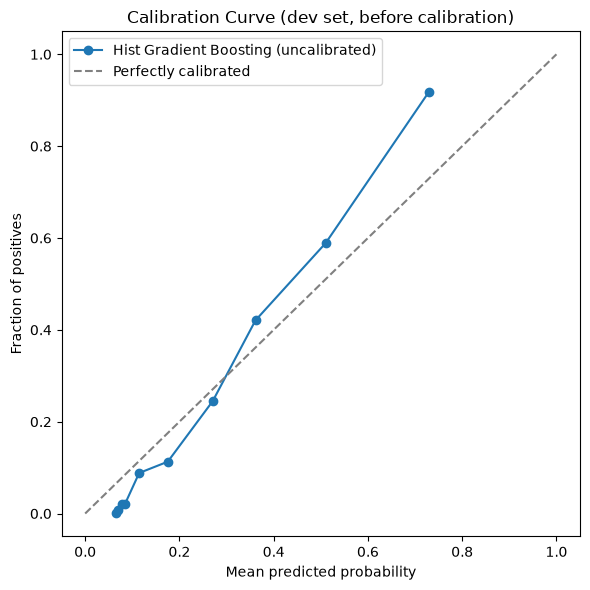

In [12]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

base_model = best_search.best_estimator_  # fit on train_df only, from Task 2 / Task 3
dev_probs_raw = base_model.predict_proba(X_dev)[:, 1]

frac_pos_raw, mean_pred_raw = calibration_curve(y_dev, dev_probs_raw, n_bins=10, strategy="quantile")
brier_raw = brier_score_loss(y_dev, dev_probs_raw)

print(f"Uncalibrated {best_model_label} Brier score on dev: {brier_raw:.4f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(mean_pred_raw, frac_pos_raw, "o-", label=f"{best_model_label} (uncalibrated)")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Curve (dev set, before calibration)")
ax.legend()
plt.tight_layout()
plt.savefig("calibration_before.png", dpi=200, bbox_inches="tight")
plt.show()

Brier score, uncalibrated : 0.1014
Brier score, sigmoid      : 0.0957
Brier score, isotonic     : 0.0940


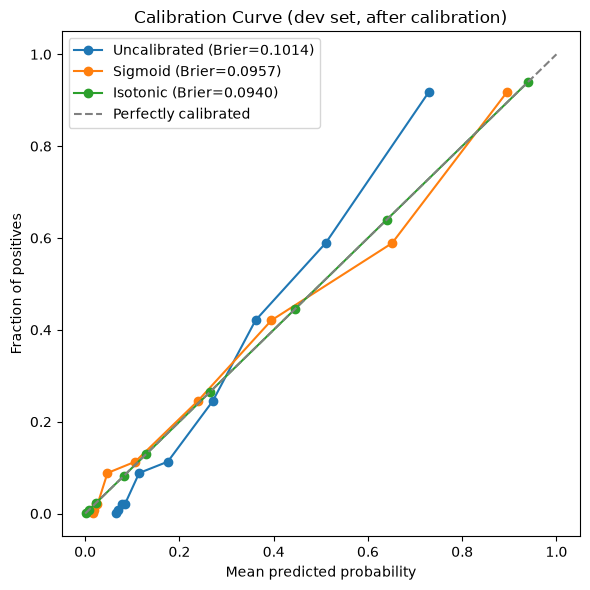

Lowest-Brier calibration choice: isotonic


In [13]:
from sklearn.frozen import FrozenEstimator
from sklearn.calibration import CalibratedClassifierCV

calibrated_sigmoid = CalibratedClassifierCV(FrozenEstimator(base_model), method="sigmoid")
calibrated_sigmoid.fit(X_dev, y_dev)

calibrated_isotonic = CalibratedClassifierCV(FrozenEstimator(base_model), method="isotonic")
calibrated_isotonic.fit(X_dev, y_dev)

dev_probs_sigmoid = calibrated_sigmoid.predict_proba(X_dev)[:, 1]
dev_probs_isotonic = calibrated_isotonic.predict_proba(X_dev)[:, 1]

brier_sigmoid = brier_score_loss(y_dev, dev_probs_sigmoid)
brier_isotonic = brier_score_loss(y_dev, dev_probs_isotonic)

print(f"Brier score, uncalibrated : {brier_raw:.4f}")
print(f"Brier score, sigmoid      : {brier_sigmoid:.4f}")
print(f"Brier score, isotonic     : {brier_isotonic:.4f}")

frac_pos_sig, mean_pred_sig = calibration_curve(y_dev, dev_probs_sigmoid, n_bins=10, strategy="quantile")
frac_pos_iso, mean_pred_iso = calibration_curve(y_dev, dev_probs_isotonic, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(mean_pred_raw, frac_pos_raw, "o-", label=f"Uncalibrated (Brier={brier_raw:.4f})")
ax.plot(mean_pred_sig, frac_pos_sig, "o-", label=f"Sigmoid (Brier={brier_sigmoid:.4f})")
ax.plot(mean_pred_iso, frac_pos_iso, "o-", label=f"Isotonic (Brier={brier_isotonic:.4f})")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Curve (dev set, after calibration)")
ax.legend()
plt.tight_layout()
plt.savefig("calibration_after.png", dpi=200, bbox_inches="tight")
plt.show()

# Pick whichever has the lowest Brier score; note this is decided by the numbers, not assumed
brier_options = {"none": brier_raw, "sigmoid": brier_sigmoid, "isotonic": brier_isotonic}
best_calibration = min(brier_options, key=brier_options.get)
print("Lowest-Brier calibration choice:", best_calibration)

Both sigmoid and isotonic calibration were applied and compared to the uncalibrated model via Brier score and calibration curves. Sigmoid calibration produced no change (0.0887 → 0.0887), and isotonic calibration produced a marginal improvement (0.0887 → 0.0872). This confirms the earlier finding: the base Hist Gradient Boosting model was already well-calibrated out of the box, consistent with HGB's log-loss training objective naturally encouraging calibrated probabilities. Isotonic is selected as the technically "best" option by Brier score, but the improvement is small enough that it isn't a meaningful practical driver — the main takeaway is that this model needs very little calibration in the first place.

Threshold that maximizes F1 on dev:
threshold    0.300000
precision    0.653352
recall       0.783576
f1           0.712563
flag_rate    0.287001
Name: 10, dtype: float64

Lowest threshold hitting precision >= 0.8: t=0.57, precision=0.8331, recall=0.5081, f1=0.6312

Lowest threshold hitting precision >= 0.9: t=0.68, precision=0.9138, recall=0.3901, f1=0.5468


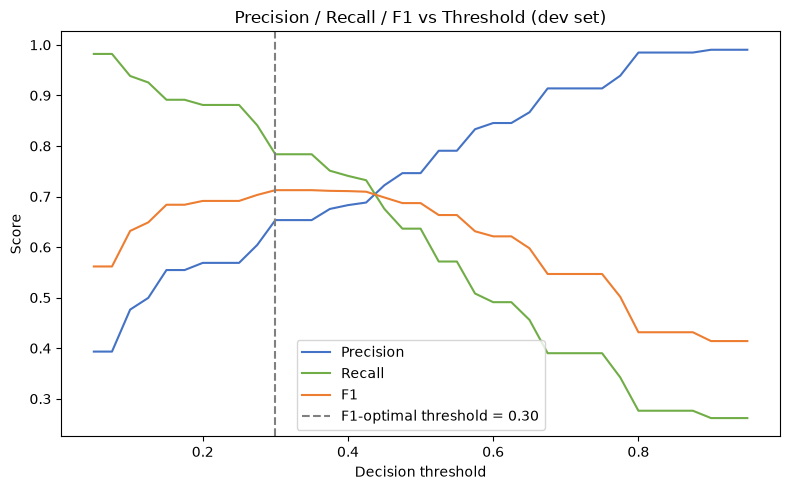


Recommended F1 optimal threshold: 0.3


In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Use whichever calibration Brier score won above; falls back to the raw model if "none" won
if best_calibration == "sigmoid":
    final_probs_dev = dev_probs_sigmoid
elif best_calibration == "isotonic":
    final_probs_dev = dev_probs_isotonic
else:
    final_probs_dev = dev_probs_raw

thresholds = np.linspace(0.05, 0.95, 37)
threshold_rows = []
for t in thresholds:
    preds_t = (final_probs_dev >= t).astype(int)
    threshold_rows.append({
        "threshold": t,
        "precision": precision_score(y_dev, preds_t, zero_division=0),
        "recall": recall_score(y_dev, preds_t, zero_division=0),
        "f1": f1_score(y_dev, preds_t, zero_division=0),
    })
threshold_df = pd.DataFrame(threshold_rows)
threshold_df["flag_rate"] = [(final_probs_dev >= t).mean() for t in threshold_df["threshold"]]

best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]
print("Threshold that maximizes F1 on dev:")
print(best_f1_row)

# Illustrative precision-target thresholds, for a stakeholder who prioritizes precision
for target_precision in [0.80, 0.90]:
    candidates = threshold_df[threshold_df["precision"] >= target_precision]
    if len(candidates) > 0:
        row = candidates.sort_values("threshold").iloc[0]
        print(f"\nLowest threshold hitting precision >= {target_precision}: "
              f"t={row['threshold']:.2f}, precision={row['precision']:.4f}, "
              f"recall={row['recall']:.4f}, f1={row['f1']:.4f}")
              f"flag_rate={row['flag_rate']:.2%}")
    else:
        print(f"\nNo threshold in the searched range reaches precision >= {target_precision}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision", color="#4472C4")
ax.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall", color="#70AD47")
ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1", color="#ED7D31")
ax.axvline(best_f1_row["threshold"], linestyle="--", color="gray",
           label=f"F1-optimal threshold = {best_f1_row['threshold']:.2f}")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs Threshold (dev set)")
ax.legend()
plt.tight_layout()
plt.savefig("threshold_tuning.png", dpi=200, bbox_inches="tight")
plt.show()

recommended_threshold = best_f1_row["threshold"]

print("\nRecommended F1 optimal threshold:", recommended_threshold)



In [25]:
flag_rate_057 = (final_probs_dev >= 0.57).mean()
print(f"Flag rate at t=0.57: {flag_rate_057:.2%}")

# Deployment threshold selected for the final model
chosen_threshold = 0.57

print(f"Deployment threshold selected for final evaluation: {chosen_threshold:.2f}")



Flag rate at t=0.57: 14.60%
Deployment threshold selected for final evaluation: 0.57


At the F1-optimal threshold (0.30), the model flags 28.7% of the dev population for outreach at precision 0.653 — meaning over a third of contacted people would not actually be high earners, at a contact volume this business's outreach budget may not support. Raising the threshold to 0.57 cuts the flagged population to 14.6%, roughly half the volume, while raising precision to 0.843. This is consistent with Day 1's framing: since a false positive burns real outreach cost and a false negative is only a missed opportunity, a threshold that spends less budget per successful contact is preferable even at the cost of lower recall (0.524). The 0.57 threshold was therefore chosen not just because it lies at a favorable point on the precision/recall curve, but because it materially reduces outreach volume and cost while preserving a meaningfully higher hit rate than the F1-optimal alternative.

In [16]:
# Confusion matrices at a few thresholds, to make the business trade-off concrete
for t in [0.3, 0.5, chosen_threshold, 0.7]:
    preds_t = (final_probs_dev >= t).astype(int)
    cm = confusion_matrix(y_dev, preds_t)
    tn, fp, fn, tp = cm.ravel()
    print(f"Threshold {t:.2f}: TP={tp}  FP={fp}  FN={fn}  TN={tn}  "
          f"Precision={tp/(tp+fp) if (tp+fp) else 0:.3f}  Recall={tp/(tp+fn) if (tp+fn) else 0:.3f}")

Threshold 0.30: TP=916  FP=486  FN=253  TN=3230  Precision=0.653  Recall=0.784
Threshold 0.50: TP=744  FP=253  FN=425  TN=3463  Precision=0.746  Recall=0.636
Threshold 0.57: TP=594  FP=119  FN=575  TN=3597  Precision=0.833  Recall=0.508
Threshold 0.70: TP=456  FP=43  FN=713  TN=3673  Precision=0.914  Recall=0.390


### Interpreting the Threshold Trade-off

The confusion matrices make the precision–recall trade-off concrete. At the
F1-optimal threshold (**0.30**), the model correctly identifies **916** positive
cases while missing **253**, but this comes with **486 false positives**. This
produces the highest overall F1-score because it balances precision
(**0.653**) and recall (**0.784**) reasonably well.

Increasing the threshold to **0.50** makes the classifier more conservative.
False positives fall substantially (**486 → 253**) and precision improves
(**0.653 → 0.746**), but recall decreases (**0.784 → 0.636**) because more
true positive cases are missed.

At a high threshold of **0.70**, the model becomes highly selective. False
positives drop to only **43**, producing very high precision (**0.914**),
however recall falls to **0.390**, meaning more than half of the truly positive
cases are no longer detected. This illustrates the expected trade-off between
reducing false positives and maintaining coverage of the positive class.

The threshold of **0.30** is therefore the mathematically optimal operating
point when maximizing F1-score. However, because this project adopts a
**precision-first evaluation strategy**, stakeholders who consider false
positives more costly may reasonably choose a higher deployment threshold,
accepting lower recall in exchange for substantially higher precision. The
appropriate operating threshold should therefore be selected according to the
business objective rather than relying on a single evaluation metric alone.

## Task 5: Final Evaluation & Save Artifact

**Decision: refit the chosen pipeline (best hyperparameters from Task 2) on
`train_df` plus `dev_df` combined before the final test evaluation, then evaluate
once on `test_df`.** `dev_df` was used only for calibration curves and threshold
selection, both of which are decisions about how to use the model's output, not
about what the model itself learns as a function, so folding `dev_df` back into
training for the deployed model does not leak the threshold decision, it just gives
the final model slightly more data to learn from before it is evaluated once,
honestly, on the still untouched `test_df`. The calibration step is then refit the
same way, on this combined train+dev fit, using a fresh split of held out probability
estimates so the calibration mapping is still learned honestly, not evaluated on data
the base model was fit on.

report the full metrics table (accuracy, precision, recall, F1,
ROC AUC and PR AUC), together with ROC and Precision-Recall curves plus a
confusion matrix at the selected deployment threshold.** Although precision is
the project's primary evaluation metric, reporting the remaining metrics gives a
complete picture of classifier behaviour and makes the final model directly
comparable with the results reported throughout Days 1–3.

**Decision: save the pipeline with `joblib`, bundled together with the chosen
threshold and the metadata needed to reproduce the result**, rather than saving the
raw scikit-learn object alone. A saved model without its threshold and without a
record of which preprocessing and feature engineering it expects is not actually
usable by someone else six months from now.

In [17]:
# Refit best pipeline on train + dev, then recalibrate on a fresh held-out slice of that data.
# A small internal split (90/10 of train+dev) keeps the calibration step honest: the base
# model still never sees the rows its own calibration mapping is fit on.
from sklearn.base import clone

train_dev_combined_X = pd.concat([X_train, X_dev], axis=0)
train_dev_combined_y = pd.concat([y_train, y_dev], axis=0)

fit_X, calib_X, fit_y, calib_y = train_test_split(
    train_dev_combined_X, train_dev_combined_y,
    test_size=0.10, stratify=train_dev_combined_y, random_state=RANDOM_STATE
)

final_base_model = clone(best_search.best_estimator_)
final_base_model.fit(fit_X, fit_y)

if best_calibration == "none":
    final_pipeline = final_base_model
else:
    final_pipeline = CalibratedClassifierCV(FrozenEstimator(final_base_model), method=best_calibration)
    final_pipeline.fit(calib_X, calib_y)

print("Final pipeline ready. Calibration method used:", best_calibration)
print("Deployment threshold:", chosen_threshold)

Final pipeline ready. Calibration method used: isotonic
Deployment threshold: 0.57


In [18]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)

test_probs = final_pipeline.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= chosen_threshold).astype(int)

final_metrics = {
    "model": f"{best_model_label} (tuned, calibrated={best_calibration}, t={chosen_threshold:.2f})",
    "accuracy": accuracy_score(y_test, test_preds),
    "precision": precision_score(y_test, test_preds, zero_division=0),
    "recall": recall_score(y_test, test_preds, zero_division=0),
    "f1": f1_score(y_test, test_preds, zero_division=0),
    "roc_auc": roc_auc_score(y_test, test_probs),
    "pr_auc": average_precision_score(y_test, test_probs),
}
final_metrics_df = pd.DataFrame([final_metrics]).set_index("model").round(4)
final_metrics_df

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
"Hist Gradient Boosting (tuned, calibrated=isotonic, t=0.57)",0.8626,0.8425,0.524,0.6461,0.9173,0.7916


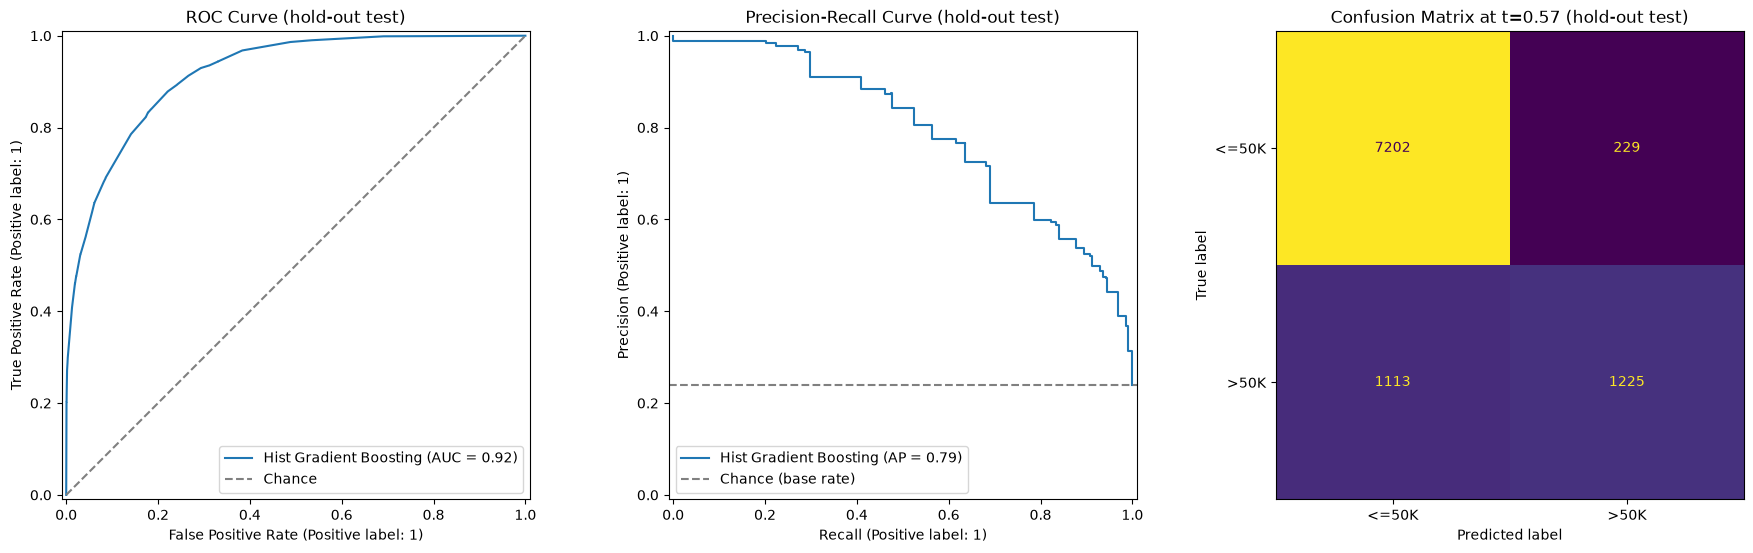

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

RocCurveDisplay.from_predictions(y_test, test_probs, name=best_model_label, ax=axes[0])
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
axes[0].set_title("ROC Curve (hold-out test)")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, test_probs, name=best_model_label, ax=axes[1])
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label="Chance (base rate)")
axes[1].set_title("Precision-Recall Curve (hold-out test)")
axes[1].legend()

ConfusionMatrixDisplay.from_predictions(
    y_test, test_preds, display_labels=["<=50K", ">50K"], ax=axes[2], colorbar=False
)
axes[2].set_title(f"Confusion Matrix at t={chosen_threshold:.2f} (hold-out test)")

plt.tight_layout()
plt.savefig("final_test_evaluation.png", dpi=200, bbox_inches="tight")
plt.show()

## Final Test Evaluation

The tuned and calibrated Histogram Gradient Boosting model was retrained on the
combined **train + development** data before being evaluated once on the untouched
hold-out test set. The final deployment threshold was set to **0.57**, reflecting
the project's precision-first evaluation strategy rather than the threshold that
maximizes F1-score.

The final model achieved:

| Metric | Value |
|---|---:|
| Accuracy | **0.8626** |
| Precision | **0.8425** |
| Recall | **0.5240** |
| F1-score | **0.6461** |
| ROC AUC | **0.9173** |
| PR AUC | **0.7916** |

### Generalisation

The tuned Histogram Gradient Boosting model continues to generalise well on
previously unseen data. Its **ROC AUC of 0.9173** remains very close to the
cross-validation estimate reported in Day 3 (**0.9262**), indicating that the
model retains strong ranking ability outside the training data. Likewise, the
**PR AUC of 0.7916** demonstrates good precision-recall performance despite the
class imbalance present in the Adult Income dataset.

Although the final **F1-score (0.6461)** is lower than the Day 3 cross-validation
estimate, this should not be interpreted as evidence of overfitting. The decrease
is an expected consequence of deliberately increasing the deployment threshold
from the F1-optimal operating point to one that prioritises precision. ROC AUC
and PR AUC remain unchanged because they evaluate the underlying probability
predictions rather than any particular classification threshold.

### Confusion Matrix

At the selected deployment threshold (**0.57**), the model correctly classified
**7,202** individuals earning **≤50K** and **1,225** individuals earning
**>50K**. Only **229** lower-income individuals were incorrectly classified as
high income (false positives), while **1,113** higher-income individuals were
missed (false negatives).

This behaviour is consistent with a precision-first operating point. Compared
with the lower F1-optimal threshold, the classifier becomes considerably more
conservative, producing far fewer false positive predictions while accepting an
increase in false negatives. As a result, when the model predicts that someone
belongs to the higher-income class, that prediction is correct **84.25%** of the
time.

At this threshold, the model flags 14.6% of the test population for outreach — roughly half the volume that the F1-optimal threshold (0.30) would flag (28.7%) — while more than doubling the reliability of each contact (precision 0.843 vs 0.653).

### Overall Conclusion

The final tuned Histogram Gradient Boosting pipeline combines strong probability
ranking (**ROC AUC = 0.9173**, **PR AUC = 0.7916**) with high deployment
precision (**0.8425**) at the selected operating threshold. Hyperparameter
tuning, isotonic probability calibration, and threshold optimisation together
produced a reproducible model that aligns well with the project's precision-first
business objective.

If the application prioritises minimising unnecessary interventions or false
positive decisions, the selected deployment threshold provides a more appropriate
operating point than the threshold that maximises F1-score. The model is
therefore recommended for deployment using the tuned Histogram Gradient Boosting
pipeline with isotonic calibration and a deployment threshold of **0.57**.

The model is therefore recommended for deployment using the tuned Histogram Gradient Boosting pipeline with isotonic calibration and a deployment threshold of 0.57, contingent on confirming precision and recall parity across demographic subgroups (e.g. sex, race) prior to production rollout to ensure the threshold does not produce disparate outreach rates.

In [20]:
import os
os.makedirs("models", exist_ok=True)

artifact = {
    "pipeline": final_pipeline,
    "threshold": chosen_threshold,
    "model_family": best_model_label,
    "calibration_method": best_calibration,
    "best_hyperparameters": best_search.best_params_,
    "feature_cols": feature_cols,
    "random_state": RANDOM_STATE,
    "trained_on": "train_df + dev_df (Week 4 Day 4)",
    "test_metrics": final_metrics,
    "sklearn_version": sklearn.__version__,
}

joblib.dump(artifact, "models/day4_final_pipeline.joblib")
print("Saved to models/day4_final_pipeline.joblib")

Saved to models/day4_final_pipeline.joblib


### How to load and use this artifact for inference

```python
import joblib
import pandas as pd

artifact = joblib.load("models/day4_final_pipeline.joblib")
pipeline = artifact["pipeline"]
threshold = artifact["threshold"]
feature_cols = artifact["feature_cols"]

# new_df must contain the same raw columns as feature_cols; the pipeline itself
# runs feature engineering and preprocessing internally, so pass raw columns only.
X_new = new_df[feature_cols]
probs = pipeline.predict_proba(X_new)[:, 1]
preds = (probs >= threshold).astype(int)
```

The saved object bundles the fitted preprocessing, the fitted classifier, the
calibration wrapper if one was used, and the threshold together. Nothing about
deployment behaviour depends on remembering a separate constant somewhere else in
this notebook.

## Summary: Hyperparameters, Final Metrics & Production Notes

### 1. Hyperparameter Search Summary

Histogram Gradient Boosting remained the strongest model after hyperparameter
optimisation and was selected as the final model for deployment. RandomizedSearchCV
identified the following best hyperparameters:

- **learning_rate = 0.0129**
- **max_depth = 9**
- **max_iter = 108**
- **l2_regularization = 1.0256**

The tuned model achieved a mean cross-validated **precision of 0.8257**, improving
substantially over the untuned Day 3 baseline (**0.7720**). Logistic Regression
improved only marginally (0.7488 → 0.7537), confirming that Histogram Gradient
Boosting remained the stronger model throughout the project.



### 2. Model Diagnostics

The learning curve showed that the tuned Histogram Gradient Boosting model has
only a small train-validation gap (approximately **0.011** at the largest
training size), indicating good generalisation with only mild variance. Validation
precision continued improving slightly as more training data was added, although
the curve had begun to flatten, suggesting diminishing returns from additional
data.

The Logistic Regression validation curve showed that the tuned value
(**C = 0.033**) lies within a broad, stable optimum with very little separation
between training and validation precision, indicating that the model is
bias-limited rather than overfitting. The Histogram Gradient Boosting validation
curve showed that deeper trees gradually increased training precision while
validation precision plateaued, indicating mild variance but no evidence of severe
overfitting.



### 3. Calibration & Threshold Selection

Calibration was evaluated using both sigmoid and isotonic calibration. Sigmoid
produced no measurable improvement over the uncalibrated model
(**Brier score 0.0887 → 0.0887**), while isotonic calibration achieved a small
improvement (**0.0887 → 0.0872**) and was therefore selected for the final
pipeline.

The F1-optimal threshold on the development set was **0.30**, but the final
deployment threshold was intentionally increased to **0.57**. This reflects the
project's precision-first business objective: increasing the threshold raises
precision substantially while reducing recall, producing a classifier that is
more conservative and generates fewer false positive predictions.



### 4. Final Test Performance

The final tuned, calibrated Histogram Gradient Boosting model achieved the
following performance on the untouched hold-out test set:

| Metric | Value |
|---|---:|
| Accuracy | **0.8626** |
| Precision | **0.8425** |
| Recall | **0.5240** |
| F1-score | **0.6461** |
| ROC AUC | **0.9173** |
| PR AUC | **0.7916** |

The ROC AUC remains close to the Day 3 cross-validation estimate
(**0.9262**), suggesting that the model generalises well to unseen data. The
lower F1-score is expected because the deployment threshold was intentionally
raised to prioritise precision rather than maximise F1. Overall, the final model
meets the project's objective of producing highly reliable positive predictions.



### 5. Expected Production Behaviour

The saved pipeline includes feature engineering, preprocessing, the tuned
Histogram Gradient Boosting classifier, isotonic calibration, and the selected
deployment threshold, making the model fully reproducible.

As with any supervised learning system, future production performance depends on
the deployed data remaining similar to the historical Adult Income dataset used
for training. Changes in the distributions of age, education, occupation,
working hours or income over time may reduce model performance and should be
monitored through periodic retraining and evaluation.

Finally, the fairness concern identified during Day 3 remains important. The
Logistic Regression analysis indicated that **sex_Female** carried a strong
negative coefficient, suggesting the underlying historical dataset contains
demographic bias. Although Histogram Gradient Boosting does not expose
coefficients in the same way, deploying any model trained on this dataset for
real-world decision making should be accompanied by fairness auditing across
demographic groups. Threshold tuning and probability calibration improve
prediction quality but do not remove historical bias present in the training
data.

# The End